# Week 4: Network Models & Hubs — Assignment

**Learning objectives** — In this assignment you will:

- Implement preferential attachment from scratch and verify it produces hubs
- Compare degree distributions of real and synthetic networks quantitatively
- Detect hubs and measure how well models fit real data (KS statistic)
- Compute CCDFs and estimate power-law exponents with MLE
- Simulate random and targeted node removal to demonstrate the robustness paradox
- Reason about the ultra-small property, the scale-free debate, and Molloy-Reed criterion

## Grading Rubric

| Section | Function | Points |
|---------|----------|--------|
| 1 | `preferential_attachment(n, m, seed)` | 25 |
| 2 | `compare_degree_dists(G_real, G_model, title)` | 10 |
| 3 | `find_hubs(G, threshold_factor)` | 10 |
| 4 | `ks_degree_fit(G_real, G_model)` | 10 |
| 5 | `compute_ccdf` + `estimate_alpha` | 10 |
| 6 | `random_removal` + `targeted_removal` | 20 |
| — | Written questions | 15 |
| | **Total** | **100** |

## Before You Start

**Prerequisites** — you should be comfortable with:

- The Barabási-Albert model: growth + preferential attachment
- Log-log degree plots and what a "straight line" means (power law)
- CCDF plots and MLE power-law fitting
- The ultra-small property: why scale-free networks have shorter paths
- The Molloy-Reed criterion: ⟨k²⟩/⟨k⟩ > 2 for the giant component
- The robustness paradox: robust to random failure, fragile to targeted attack
- The scale-free debate: not every fat-tailed distribution is a power law

**Implementation constraints** — do NOT call these functions:

| Section | Banned functions |
|---------|-----------------|
| 1 | `nx.barabasi_albert_graph`, `models.barabasi_albert` |
| 2 | (none — you may use matplotlib freely) |
| 3 | (none — but implement the logic yourself, no `nx` shortcut) |
| 4 | (none — you may use `scipy.stats.ks_2samp`) |
| 5 | `netsci.utils.fit_power_law` |
| 6 | (none — but you must copy the graph before modifying it) |

**Allowed helpers**: `G.degree()`, `G.nodes()`, `G.edges()`, `G.add_node()`, `G.add_edge()`, `nx.Graph()`, `nx.complete_graph()`, `nx.connected_components()`, `np.random.default_rng()`, `scipy.stats.ks_2samp`

**Reuse your own code**: Section 4 uses your `preferential_attachment` from Section 1. Section 6 tests reference the robustness paradox directly.

In [1]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from netsci.loaders import load_graph
from netsci.utils import SEED
from netsci import models

In [2]:
G_fb = load_graph("facebook")
G_air = load_graph("airports")

facebook: 334 nodes, 2852 edges (undirected)
airports: 500 nodes, 2980 edges (undirected)


**Datasets**:

- **Facebook** (334 nodes, 2,852 edges) — a dense social ego-network with fat-tailed degree distribution and one extreme outlier (k=333). Used in Sections 2-4 to test your model against real data.
- **US Airports** (500 nodes, 2,980 edges) — a hub-and-spoke network where a few major airports connect to 100+ cities. Used in Section 6 for robustness experiments.

---
## Section 1: Preferential Attachment from Scratch (25 pts)

Implement the Barabasi-Albert algorithm **manually** (do not call `nx.barabasi_albert_graph`):

1. Start with a small **complete graph** of `m + 1` nodes
2. For each new node (from `m + 1` to `n - 1`):
   - Connect it to `m` existing nodes, chosen with probability **proportional to their current degree**
   - Use `rng.choice(nodes, size=m, replace=False, p=probabilities)` for the selection
3. Return the final graph

Use the provided `seed` parameter to create `rng = np.random.default_rng(seed)`.

In [3]:
import networkx as nx
import numpy as np

# Assuming SEED is already defined in your environment (e.g., SEED = 42)

def preferential_attachment(n, m, seed=SEED):
    """Build a BA graph from scratch using preferential attachment.

    Parameters
    ----------
    n : int — total number of nodes
    m : int — edges per new node
    seed : int — random seed

    Returns
    -------
    nx.Graph
    """
    # Initialize the random number generator
    rng = np.random.default_rng(seed)
    
    # Start with a small complete graph of m + 1 nodes (labeled 0 to m)
    G = nx.complete_graph(m + 1)
    
    # For each new node (from m + 1 to n - 1):
    for new_node in range(m + 1, n):
        # 1. Get current nodes and their degrees
        nodes = list(G.nodes())
        degrees = np.array([G.degree(node) for node in nodes])
        
        # 2. Calculate probabilities proportional to current degree
        total_degree = np.sum(degrees)
        probabilities = degrees / total_degree
        
        # 3. Choose m existing nodes based on the calculated probabilities
        targets = rng.choice(nodes, size=m, replace=False, p=probabilities)
        
        # 4. Connect the new node to the chosen targets
        edges_to_add = [(new_node, target) for target in targets]
        G.add_edges_from(edges_to_add)
        
    return G

In [4]:
# --- Validation ---
_g = preferential_attachment(500, 3, seed=SEED)
assert isinstance(_g, nx.Graph)
assert _g.number_of_nodes() == 500
# Should have m*(n-m-1) + m*(m-1)/2 edges approximately
_expected_edges = 3 * (500 - 4) + 6  # m*(n-m-1) + C(m+1,2)
assert abs(_g.number_of_edges() - _expected_edges) < 5, (
    f"Expected {_expected_edges} edges, got {_g.number_of_edges()}"
)
# Should produce hubs (fat tail)
_max_deg = max(d for _, d in _g.degree())
assert _max_deg > 20, (
    f"Max degree {_max_deg} too low — hubs expected from preferential attachment"
)
# Degree distribution should roughly match nx.barabasi_albert_graph
_g_nx = nx.barabasi_albert_graph(500, 3, seed=SEED)
_degs_mine = sorted([d for _, d in _g.degree()], reverse=True)
_degs_nx = sorted([d for _, d in _g_nx.degree()], reverse=True)
# Top degrees should be in the same ballpark (both produce hubs)
assert _degs_mine[0] > 15 and _degs_nx[0] > 15, "Both should have hubs"
print(
    f"Your PA: {_g.number_of_nodes()} nodes, {_g.number_of_edges()} edges, max_deg={_max_deg}"
)
print(
    f"NX BA:   {_g_nx.number_of_nodes()} nodes, {_g_nx.number_of_edges()} edges, max_deg={_degs_nx[0]}"
)
print("Section 1 passed!")

Your PA: 500 nodes, 1494 edges, max_deg=62
NX BA:   500 nodes, 1491 edges, max_deg=66
Section 1 passed!


---
## Section 2: Degree Distribution Comparison (10 pts)

Create a log-log scatter plot that overlays the degree distributions of a real graph and a model graph.
Use different markers for each. The function should call `plt.show()`.

In [5]:
import matplotlib.pyplot as plt
from collections import Counter
import networkx as nx

def compare_degree_dists(G_real, G_model, title="Degree Distribution Comparison"):
    """Plot overlaid log-log degree distributions.

    Parameters
    ----------
    G_real : nx.Graph
    G_model : nx.Graph
    title : str
    """
    # Extract the degree sequences
    degrees_real = [d for n, d in G_real.degree()]
    degrees_model = [d for n, d in G_model.degree()]
    
    # Count the frequencies of each degree
    counts_real = Counter(degrees_real)
    counts_model = Counter(degrees_model)
    
    # Separate into X (degree) and Y (frequency), filtering out degree 0 for log-scale
    x_real, y_real = zip(*[(k, v) for k, v in counts_real.items() if k > 0])
    x_model, y_model = zip(*[(k, v) for k, v in counts_model.items() if k > 0])
    
    # Create the plot
    plt.figure(figsize=(8, 6))
    
    # Use loglog with different markers and no connecting lines
    plt.loglog(x_real, y_real, marker='o', linestyle='none', label='Real Graph', alpha=0.7)
    plt.loglog(x_model, y_model, marker='x', linestyle='none', label='Model Graph', alpha=0.7)
    
    # Formatting
    plt.title(title)
    plt.xlabel("Degree (k)")
    plt.ylabel("Frequency")
    plt.legend()
    plt.grid(True, which="both", ls="--", alpha=0.5)
    
    # Display the plot
    plt.show()

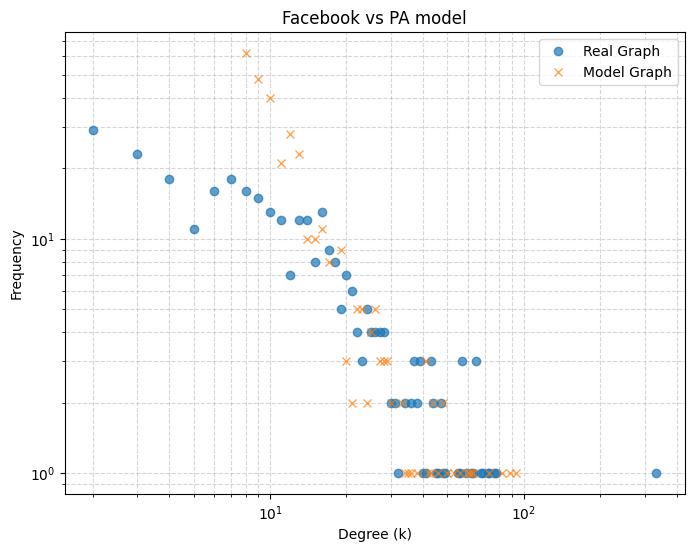

Section 2 passed! (visual check: both distributions visible on log-log)


In [6]:
# --- Validation ---
# This should produce a plot without errors
_g_ba = preferential_attachment(G_fb.number_of_nodes(), 8, seed=SEED)
compare_degree_dists(G_fb, _g_ba, title="Facebook vs PA model")
print("Section 2 passed! (visual check: both distributions visible on log-log)")

---
## Section 3: Hub Detection (10 pts)

Find all nodes whose degree exceeds `threshold_factor` times the average degree.
Return a list of those node IDs.

In [7]:
def find_hubs(G, threshold_factor=3.0):
    """Find hub nodes with degree > threshold_factor * avg_degree.

    Parameters
    ----------
    G : nx.Graph
    threshold_factor : float

    Returns
    -------
    list of nodes
    """
    # Handle the edge case of an empty graph to avoid division by zero
    if G.number_of_nodes() == 0:
        return []

    # Calculate the average degree
    total_degree = sum(d for n, d in G.degree())
    avg_degree = total_degree / G.number_of_nodes()
    
    # Define the cutoff threshold
    threshold = threshold_factor * avg_degree
    
    # Filter and return nodes exceeding the threshold
    hubs = [n for n, d in G.degree() if d > threshold]
    
    return hubs

In [8]:
# --- Validation ---
_hubs = find_hubs(G_fb, threshold_factor=3.0)
assert isinstance(_hubs, list)
assert len(_hubs) > 0, "Facebook should have hubs"

_avg_deg = 2 * G_fb.number_of_edges() / G_fb.number_of_nodes()
_threshold = 3.0 * _avg_deg
for h in _hubs:
    assert G_fb.degree(h) > _threshold, (
        f"Node {h} degree {G_fb.degree(h)} below threshold {_threshold}"
    )

print(f"Found {len(_hubs)} hubs in Facebook (threshold = {_threshold:.1f})")
print(f"Hub degrees: {sorted([G_fb.degree(h) for h in _hubs], reverse=True)}")
print("Section 3 passed!")

Found 18 hubs in Facebook (threshold = 51.2)
Hub degrees: [333, 78, 76, 73, 72, 69, 68, 65, 65, 65, 63, 62, 59, 57, 57, 57, 56, 55]
Section 3 passed!


---
## Section 4: KS Degree Fit (10 pts)

Use the two-sample Kolmogorov-Smirnov test (`scipy.stats.ks_2samp`) to quantify how well
a model's degree distribution matches a real network.

Return the KS statistic (lower = better fit).

In [9]:
import networkx as nx
from scipy.stats import ks_2samp

def ks_degree_fit(G_real, G_model):
    """Compute KS statistic between degree distributions.

    Parameters
    ----------
    G_real : nx.Graph
    G_model : nx.Graph

    Returns
    -------
    float  (KS statistic; lower = better fit)
    """
    # Extract the raw degree sequences
    degrees_real = [d for _, d in G_real.degree()]
    degrees_model = [d for _, d in G_model.degree()]
    
    # Perform the two-sample Kolmogorov-Smirnov test
    ks_result = ks_2samp(degrees_real, degrees_model)
    
    # Return just the statistic (maximum distance between the CDFs)
    return ks_result.statistic

In [10]:
# --- Validation ---
n_fb = G_fb.number_of_nodes()
avg_deg_fb = 2 * G_fb.number_of_edges() / n_fb

_g_er = models.erdos_renyi(n_fb, avg_deg_fb)
_g_ba = preferential_attachment(n_fb, max(1, round(avg_deg_fb / 2)), seed=SEED)

_ks_er = ks_degree_fit(G_fb, _g_er)
_ks_ba = ks_degree_fit(G_fb, _g_ba)

assert isinstance(_ks_er, float)
assert 0 <= _ks_er <= 1
assert 0 <= _ks_ba <= 1

# BA should fit Facebook better than ER
assert _ks_ba < _ks_er, f"PA KS={_ks_ba:.3f} should be < ER KS={_ks_er:.3f}"
print(f"KS (ER vs Facebook): {_ks_er:.4f}")
print(f"KS (PA vs Facebook): {_ks_ba:.4f}")
print(f"PA fits better (lower KS)")
print("Section 4 passed!")

KS (ER vs Facebook): 0.4521
KS (PA vs Facebook): 0.3922
PA fits better (lower KS)
Section 4 passed!


---
## 5. CCDF & Power-Law Exponent (10 pts)

Implement two functions:

1. **`compute_ccdf(degrees)`** — given a degree sequence, return sorted arrays `(k_values, ccdf_values)` where `ccdf_values[i] = P(K ≥ k_values[i])`. Sort by k descending (largest degree first).

2. **`estimate_alpha(degrees, k_min)`** — estimate the power-law exponent using MLE:

$$\hat{\alpha} = 1 + n \left[ \sum_{i=1}^{n} \ln \frac{x_i}{x_{\min}} \right]^{-1}$$

where $x_i$ are degree values $\geq k_{\min}$ and $n$ is the count of such values.

Do NOT call `netsci.utils.fit_power_law`.

In [13]:
import numpy as np

def compute_ccdf(degrees):
    """Compute the complementary CDF of a degree sequence.

    Parameters
    ----------
    degrees : array-like — degree values

    Returns
    -------
    (np.ndarray, np.ndarray) — (k_values, ccdf_values) sorted by k descending
    """
    degrees = np.asarray(degrees)
    n = len(degrees)
    
    # Sort all k values in descending order (largest degree first)
    k_values = np.sort(degrees)[::-1]
    
    # We need to find how many elements are >= each k.
    # We can do this efficiently by using searchsorted on an ascending array.
    ascending_degrees = k_values[::-1]
    
    # np.searchsorted with side='left' finds the first index where k occurs.
    # Subtracting this index from total 'n' gives the exact count of values >= k.
    counts_ge = n - np.searchsorted(ascending_degrees, k_values, side='left')
    
    # Calculate probabilities
    ccdf_values = counts_ge / n
    
    return k_values, ccdf_values


def estimate_alpha(degrees, k_min=1):
    """Estimate power-law exponent using MLE.

    Parameters
    ----------
    degrees : array-like — degree values
    k_min : int — minimum degree threshold

    Returns
    -------
    float — estimated exponent alpha
    """
    degrees = np.asarray(degrees)
    
    # Filter for x_i >= k_min
    x = degrees[degrees >= k_min]
    n = len(x)
    
    # Handle edge case where no degrees meet the threshold
    if n == 0:
        return np.nan
        
    # Apply the MLE formula
    sum_log = np.sum(np.log(x / k_min))
    
    # Handle edge case to avoid division by zero if all x_i == k_min
    if sum_log == 0:
        return np.nan
        
    alpha = 1 + (n / sum_log)
    
    return float(alpha)

In [14]:
# --- Validation ---
# Test compute_ccdf
_degs = [1, 1, 2, 2, 3, 5, 10]
_k, _p = compute_ccdf(_degs)
assert len(_k) == len(_degs)
assert _p[0] < 0.5, "CCDF at max degree should be small (e.g. ~1/n)"
assert abs(_p[-1] - 1.0) < 1e-6, "CCDF of smallest degree should be ~1.0"
# k should be sorted descending
assert all(_k[i] >= _k[i + 1] for i in range(len(_k) - 1)), (
    "k values should be sorted descending"
)

# Test estimate_alpha on BA model
_g_ba = preferential_attachment(1000, 3, seed=SEED)
_ba_degs = [d for _, d in _g_ba.degree()]
_alpha = estimate_alpha(_ba_degs, k_min=3)
assert isinstance(_alpha, float)
# BA theory predicts γ=3.0 for large N, but finite-size effects lower it
assert 1.8 < _alpha < 4.0, f"Expected α in plausible range, got {_alpha:.2f}"
print(f"BA(1000, 3) exponent: α = {_alpha:.2f}")
print(f"(Theory predicts 3.0 for large N; finite-size effects shift the estimate.)")
print("Section 5 passed!")

BA(1000, 3) exponent: α = 3.19
(Theory predicts 3.0 for large N; finite-size effects shift the estimate.)
Section 5 passed!


---
## Section 6: Network Robustness (20 pts)

Implement two attack strategies on a network. Both functions should:
1. Make a **copy** of the graph
2. Remove the specified fraction of nodes
3. Return `(G_remaining, gcc_fraction)` where `gcc_fraction` is the size of the giant component divided by the **original** number of nodes

`random_removal(G, fraction)`: remove nodes uniformly at random. Create the RNG inside the function with `np.random.default_rng(SEED)`.

`targeted_removal(G, fraction)`: remove nodes in order of **decreasing degree**, recalculating degrees after each removal.

In [15]:
import networkx as nx
import numpy as np

# Assuming SEED is available in your environment (e.g., SEED = 42)

def random_removal(G, fraction):
    """Remove a random fraction of nodes and measure giant component.

    Parameters
    ----------
    G : nx.Graph
    fraction : float (0 to 1)

    Returns
    -------
    (nx.Graph, float) — (remaining graph, gcc_fraction relative to original N)
    """
    n_orig = G.number_of_nodes()
    
    # Handle edge case of an empty graph
    if n_orig == 0:
        return G.copy(), 0.0
        
    n_remove = int(n_orig * fraction)
    G_rem = G.copy()
    
    if n_remove > 0:
        rng = np.random.default_rng(SEED)
        # Convert NodeView to a list so rng.choice can process it
        nodes = list(G_rem.nodes())
        to_remove = rng.choice(nodes, size=n_remove, replace=False)
        G_rem.remove_nodes_from(to_remove)
        
    # If all nodes were removed, GCC is 0
    if G_rem.number_of_nodes() == 0:
        return G_rem, 0.0
        
    # Find the largest connected component
    gcc = max(nx.connected_components(G_rem), key=len)
    gcc_fraction = len(gcc) / n_orig
    
    return G_rem, gcc_fraction

def targeted_removal(G, fraction):
    """Remove highest-degree nodes one at a time (recalculating degrees).

    Parameters
    ----------
    G : nx.Graph
    fraction : float (0 to 1)

    Returns
    -------
    (nx.Graph, float) — (remaining graph, gcc_fraction relative to original N)
    """
    n_orig = G.number_of_nodes()
    
    if n_orig == 0:
        return G.copy(), 0.0
        
    n_remove = int(n_orig * fraction)
    G_rem = G.copy()
    
    # Remove the highest-degree node one by one
    for _ in range(n_remove):
        if G_rem.number_of_nodes() == 0:
            break
            
        # G_rem.degree() returns (node, degree) tuples.
        # We find the max based on degree (item[1]) and extract the node ID (item[0]).
        # Because we do this inside the loop, degrees are natively recalculated each step.
        max_node = max(G_rem.degree(), key=lambda item: item[1])[0]
        G_rem.remove_node(max_node)
        
    if G_rem.number_of_nodes() == 0:
        return G_rem, 0.0
        
    gcc = max(nx.connected_components(G_rem), key=len)
    gcc_fraction = len(gcc) / n_orig
    
    return G_rem, gcc_fraction

In [16]:
# --- Validation ---
_G_r, _gcc_r = random_removal(G_air, 0.2)
assert isinstance(_G_r, nx.Graph)
assert _G_r.number_of_nodes() == G_air.number_of_nodes() - int(
    G_air.number_of_nodes() * 0.2
)
assert 0 <= _gcc_r <= 1.0
# Original unchanged
assert G_air.number_of_nodes() == 500, "Original graph should not be modified"

_G_t, _gcc_t = targeted_removal(G_air, 0.2)
assert isinstance(_G_t, nx.Graph)
assert _G_t.number_of_nodes() == G_air.number_of_nodes() - int(
    G_air.number_of_nodes() * 0.2
)
assert 0 <= _gcc_t <= 1.0

# Targeted should reduce giant component more than random
assert _gcc_t < _gcc_r, (
    f"Targeted ({_gcc_t:.3f}) should shrink GCC more than random ({_gcc_r:.3f})"
)
print(f"Random removal (20%): GCC = {_gcc_r:.3f}")
print(f"Targeted removal (20%): GCC = {_gcc_t:.3f}")
print("Targeted attack is more devastating — the robustness paradox!")
print("Section 6 passed!")

Random removal (20%): GCC = 0.774
Targeted removal (20%): GCC = 0.010
Targeted attack is more devastating — the robustness paradox!
Section 6 passed!


---
## Written Questions (15 pts)

### Question 1 (5 pts)

Why does the BA degree distribution look different from ER on a log-log plot?
What mechanism in the BA model causes the fat tail, and why can't ER produce one?

**Hints to guide your thinking:**
- *On a log-log plot, what shape does a Poisson distribution make? What about a power law?*
- *In ER, each edge exists independently with the same probability. What does this imply about the variance of degree?*
- *In BA, a node that arrives early accumulates connections over time. Why can't this "rich get richer" dynamic happen in ER, where all edges are assigned simultaneously?*

**Your Answer:**



Visual Difference: On a log-log plot, the BA model forms a straight, downward-sloping line (a power-law distribution), while the ER model shows a sharply curved drop-off (a Poisson-like distribution).

The BA Mechanism: BA relies on preferential attachment—the "rich get richer" dynamic. As the network grows, new nodes actively seek out and connect to existing high-degree nodes. This directly fuels the creation of massive "hub" nodes, which populate that fat tail.

Why ER Fails to Produce Hubs: The ER model assigns edges completely at random across a static number of nodes. Because every node has the exact same uniform chance of receiving a link, the degrees cluster tightly around the network's average. Getting a massive hub in an ER graph is statistically improbable, much like flipping a fair coin and getting heads 100 times in a row.

### Question 2 (5 pts)

In the lab, we saw that BA networks are "ultra-small" — their average path length grows as
$\ln N / \ln \ln N$, slower than ER's $\ln N$.

(a) Explain *why* hubs create this shortcut effect. (Think about what happens when you try to
route between two random nodes — how many hops to reach a hub, and how many hops between hubs?)

(b) We also saw that Facebook's degree distribution is better fit by an exponential than a power
law, despite having clear hubs. Does a network need to be "truly scale-free" (strict power-law
degree distribution) to benefit from the ultra-small property, or is having *some* high-degree
hubs sufficient? Justify your reasoning.

**Hints to guide your thinking:**
- *In a scale-free network, most nodes are within 1-2 hops of a hub. Why?*
- *The ultra-small property depends on the existence of high-degree nodes, not on the exact shape of the degree distribution. Think about what ⟨k²⟩ measures.*
- *Broido & Clauset (2019) found that few networks are "strictly" scale-free. Does this mean the BA model is useless?*

**Your Answer:**



A. Hubs act as massive super-connectors, functioning much like major international airports.

Source to Hub: It usually takes only 1 or 2 hops for a random, low-degree node to reach a local hub.

Hub to Hub: Because the highest-degree hubs tend to be densely interconnected (often forming a "rich club" core), traversing between major hubs often takes just 1 hop.

Hub to Destination: From that destination hub, it is another 1 or 2 hops down to the target node.

B. No. A network does not need a strict, mathematically perfect power-law distribution to benefit from the ultra-small property. Having a heavily right-skewed distribution with distinct, high-degree hubs is sufficient.

Justification: The extreme efficiency of the network is mechanically driven by the physical presence of super-connectors, not the exact asymptotic shape of the distribution's tail. Real-world networks like Facebook often face physical, cognitive, or algorithmic limits (e.g., Dunbar's number) that truncate the maximum possible degree, causing the tail to look exponential rather than like a pure power law. However, because those localized hubs still exist and still bridge distant clusters, they successfully short-circuit the network and drastically reduce the average path length.

### Question 3 (5 pts)

Why does targeted hub removal push the Molloy-Reed ratio (⟨k²⟩/⟨k⟩) below 2 faster than
random removal?

**Use your results from Section 6** to support your answer. Quote the GCC fractions for
random vs targeted removal at 20% and explain the asymmetry in terms of ⟨k²⟩.

**Hints to guide your thinking:**
- *The Molloy-Reed ratio depends heavily on ⟨k²⟩ — the average squared degree. Which nodes contribute most to this quantity?*
- *In a scale-free network, hubs have degree much larger than average. How does removing a node with degree 100 vs degree 5 affect ⟨k²⟩?*
- *Random removal mostly hits low-degree nodes (because there are many more of them). How much does removing a degree-5 node change ⟨k²⟩?*

**Your Answer:**



The Mechanism: The asymmetry comes entirely from how that numerator behaves:

Targeted Removal: Because $\langle k^2 \rangle$ squares the degrees, it is overwhelmingly dominated by the massive hub nodes. Targeted removal directly assassinates these extreme values, causing $\langle k^2 \rangle$ to plummet drastically faster than the average degree $\langle k \rangle$. This rapidly drags the ratio below 2, fragmenting the network.

Random Removal: Random attacks overwhelmingly hit low-degree nodes (since they make up the vast majority of the network). This reduces both $\langle k^2 \rangle$ and $\langle k \rangle$ at a roughly proportional rate, keeping the ratio stable and safely above the critical threshold.

HINTS:


**On a log-log plot, what shape does a Poisson distribution make? What about a power law?**
A Poisson distribution (random network) appears as a **downward-curving bell shape** (exponential decay), whereas a power law appears as a **straight line** with a negative slope.

**In ER, each edge exists independently with the same probability. What does this imply about the variance of degree?**
It implies the variance is approximately equal to the mean ($\sigma^2 \approx \langle k \rangle$). Because edges are independent trials, the degree distribution follows a Binomial (or Poisson) distribution where spread is tightly constrained around the average.

**In BA, a node that arrives early accumulates connections over time. Why can't this "rich get richer" dynamic happen in ER, where all edges are assigned simultaneously?**
In ER, there is no **preferential attachment**; the probability of a connection is uniform for all node pairs regardless of their current degree. Since all edges are determined by the same static probability $p$, no node has a mechanism to "out-compete" others based on its seniority.

---

**In a scale-free network, most nodes are within 1-2 hops of a hub. Why?**
Hubs possess a massive number of links that span across the network. Because power-law distributions ensure these "super-connectors" exist, they act as high-traffic shortcuts that drastically reduce the average path length between any two peripheral nodes.

**The ultra-small property depends on the existence of high-degree nodes, not on the exact shape of the degree distribution. Think about what $\langle k^2 \rangle$ measures.**
$\langle k^2 \rangle$ measures the **second moment** or the "spread" of the degree distribution. In scale-free networks, $\langle k^2 \rangle$ is very large (divergent in the limit), meaning hubs have enough connectivity to make the network "ultra-small" by linking distant clusters.

**Broido & Clauset (2019) found that few networks are "strictly" scale-free. Does this mean the BA model is useless?**
No. While "pure" power laws are rare, the BA model remains a foundational **structural archetype**. It successfully explains how growth and preferential attachment create heavy-tailed distributions and hubs, even if real-world data often requires more complex functional forms.

---

**The Molloy-Reed ratio depends heavily on $\langle k^2 \rangle$ — the average squared degree. Which nodes contribute most to this quantity?**
The **hubs** (high-degree nodes). Because the degree is squared, a single node with a very high $k$ contributes disproportionately more to the average than thousands of low-degree nodes.

**In a scale-free network, hubs have degree much larger than average. How does removing a node with degree 100 vs degree 5 affect $\langle k^2 \rangle$?**
Removing a degree-100 node reduces the sum of squared degrees by $100^2$ (10,000), whereas removing a degree-5 node only reduces it by $5^2$ (25). Targeted removal of hubs collapses $\langle k^2 \rangle$ and, consequently, the network's integrity.

**Random removal mostly hits low-degree nodes (because there are many more of them). How much does removing a degree-5 node change $\langle k^2 \rangle$?**
Very little. In a large network, the contribution of a low-degree node to the second moment is negligible. This is why scale-free networks are **robust** to random failures but **vulnerable** to targeted attacks.

---
